# 11. 基于遮蔽攻击的对抗性训练

## 11.0 主要内容介绍

在之前的实验中，我们学习了基于模型可解释性之梯度积分法的遮蔽攻击（Inductive Occlusion Attack, IOA），以及基于PGD攻击的对抗性训练。

在本节中，我们将在MNIST数据集上实现遮蔽攻击，并基于遮蔽攻击进行专门的对抗性训练，以提升模型对遮蔽攻击的鲁棒性。

本实验的主要内容为采用Python、PyTorch、Captum等技术，实现基于遮蔽攻击的对抗性训练，并进行鲁棒性测试。

## 11.1 导入相关模块

In [3]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import logging

from tabulate import tabulate
import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from occlusion_attack import OcclusionAttack
from adversarial_training import OcclusionAdversarialTraining
from utils import load_mnist_test
from models import LeNet5, FCNet


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 11.2 遮蔽攻击（Inductive Occlusion Attack）在MNIST上的实现

遮蔽攻击的核心思想是利用梯度积分（Integrated Gradients）来确定图像中最重要的区域，然后用特定颜色的遮蔽块覆盖这些区域，从而欺骗模型。

具体步骤为：
1. 使用梯度积分计算每个像素的重要性
2. 通过卷积操作计算每个区域的重要性之和
3. 选择最重要的top_k个区域中心
4. 用kernel_size × kernel_size的遮蔽窗口覆盖这些区域

与CIFAR-10上的实现不同，MNIST为单通道灰度图像（1×28×28），因此在卷积操作中输入通道数为1。

### 11.2.1 加载标准模型并测试遮蔽攻击效果

In [ ]:
# 加载标准训练的LeNet5模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

print('标准LeNet5模型加载完成')

In [5]:
# 加载MNIST测试集
imgs, lbls = load_mnist_test()

# 测试标准模型在干净样本上的准确率
cln_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')
logger.info(f'标准模型 - 干净样本准确率: {cln_acc:.2f}%')

208472 20260328 16:04:35 标准模型 - 干净样本准确率: 99.00%
208472 20260328 16:04:35 标准模型 - 干净样本准确率: 99.00%


In [6]:
# 测试遮蔽攻击对标准模型的效果
occlusion = OcclusionAttack(std_lenet, top_k=9, occlu_color=0.0, kernel_size=3)
occ_acc, _ = test_fn(nn.Sequential(occlusion, std_lenet), imgs, lbls, bs=250, mode='attack')
logger.info(f'标准模型 - 遮蔽攻击后准确率: {occ_acc:.2f}%')

208472 20260328 16:04:42 标准模型 - 遮蔽攻击后准确率: 28.64%
208472 20260328 16:04:42 标准模型 - 遮蔽攻击后准确率: 28.64%


真实标签: 0


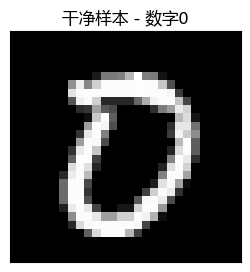

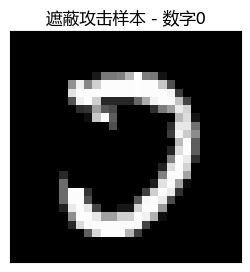

真实标签: 6


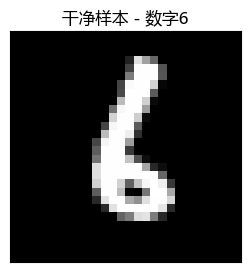

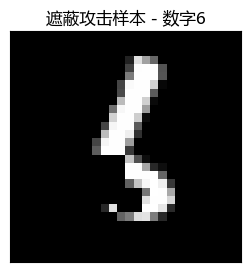

真实标签: 5


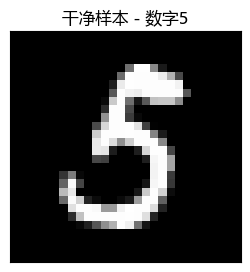

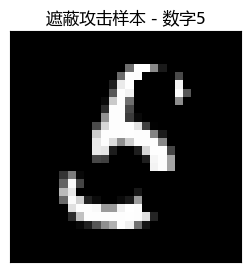

真实标签: 1


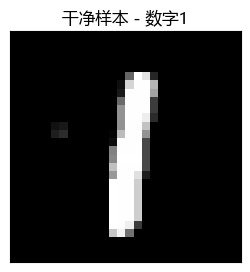

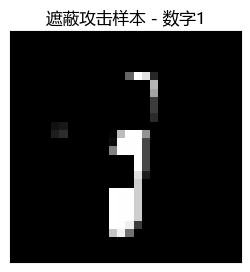

真实标签: 8


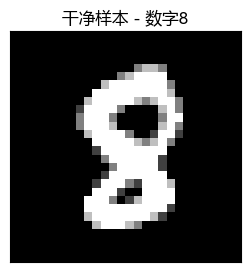

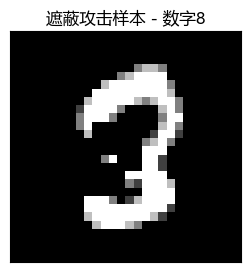

真实标签: 3


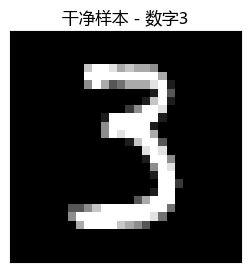

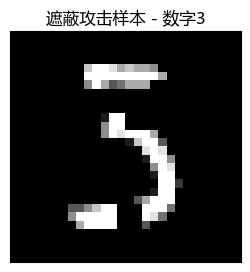

真实标签: 7


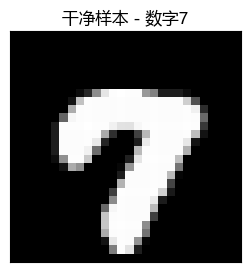

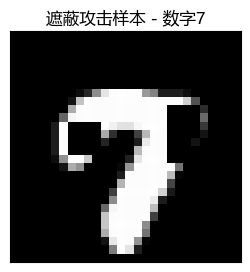

真实标签: 4


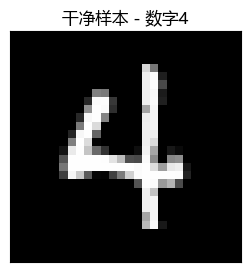

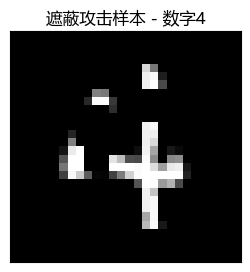

真实标签: 9


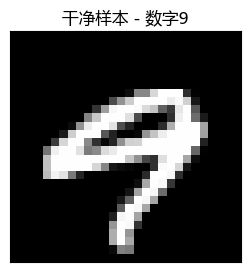

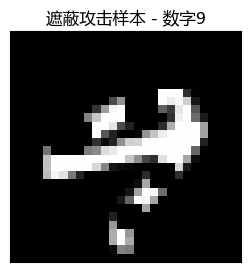

真实标签: 2


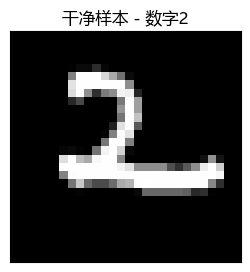

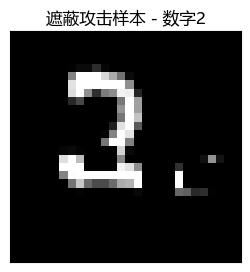

In [7]:
# 可视化遮蔽攻击效果
# 解决中文标题显示为方块/乱码（按顺序尝试可用中文字体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def imshow_mnist(img, title=''):
    npimg = img.cpu().squeeze().numpy()
    plt.figure(figsize=(3, 3))
    plt.imshow(npimg, cmap='gray')
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()
# 取一个batch进行可视化（每个数字类别显示一个样本）
sample_x = imgs[:250].to(device)
sample_y = lbls[:250].to(device)
std_lenet.eval()
sample_adv = occlusion((sample_x, sample_y))

# 找到0-9每个数字在当前batch中的第一个样本索引
shown_labels = set()
selected_indices = []
for i in range(sample_y.shape[0]):
    label = int(sample_y[i].item())
    if label not in shown_labels:
        shown_labels.add(label)
        selected_indices.append(i)
    if len(shown_labels) == 10:
        break
for idx in selected_indices:
    label = int(sample_y[idx].item())
    print(f'真实标签: {label}')
    imshow_mnist(sample_x[idx], f'干净样本 - 数字{label}')
    imshow_mnist(sample_adv[idx], f'遮蔽攻击样本 - 数字{label}')


In [ ]:
# ========== 攻击样本预测结果分析 ==========
# 分析攻击样本被识别为哪个类别，统计错分情况

import pandas as pd
from collections import defaultdict

# 使用默认值，不依赖后面cell定义的变量
TOP_K_ANALYSIS = 5               # 默认分析用top_k
OCCLU_COLOR_ANALYSIS = 0.0       # 默认遮蔽颜色
KERNEL_SIZE_ANALYSIS = 3         # 默认kernel_size

def analyze_attack_predictions(model, attack, imgs, lbls, attack_name="Attack", num_samples=1000):
    """
    分析攻击前后样本的预测结果变化
    返回：
        - 攻击前准确率
        - 攻击后准确率
        - 错分样本统计（原始标签 -> 错误预测标签 -> 数量）
    """
    model.eval()
    
    # 取前num_samples个样本
    sample_imgs = imgs[:num_samples].to(device)
    sample_lbls = lbls[:num_samples].to(device)
    
    with torch.no_grad():
        # 干净样本预测
        clean_outputs = model(sample_imgs)
        clean_preds = clean_outputs.max(dim=1).indices
        
        # 对抗样本预测
        adv_imgs = attack((sample_imgs, sample_lbls))
        adv_outputs = model(adv_imgs)
        adv_preds = adv_outputs.max(dim=1).indices
    
    # 计算准确率
    clean_acc = (clean_preds == sample_lbls).sum().item() / num_samples * 100
    adv_acc = (adv_preds == sample_lbls).sum().item() / num_samples * 100
    
    # 统计错分情况：原始标签 -> 被错分为哪个标签
    misclassify_map = defaultdict(lambda: defaultdict(int))
    
    for i in range(num_samples):
        true_label = int(sample_lbls[i].item())
        clean_pred = int(clean_preds[i].item())
        adv_pred = int(adv_preds[i].item())
        
        # 只统计攻击成功的样本（攻击前正确，攻击后错误）
        if clean_pred == true_label and adv_pred != true_label:
            misclassify_map[true_label][adv_pred] += 1
    
    print(f"\n{'='*60}")
    print(f"攻击类型: {attack_name}")
    print(f"测试样本数: {num_samples}")
    print(f"攻击前准确率: {clean_acc:.2f}%")
    print(f"攻击后准确率: {adv_acc:.2f}%")
    print(f"攻击成功率: {clean_acc - adv_acc:.2f}%")
    print(f"{'='*60}")
    
    # 打印错分统计
    if misclassify_map:
        print(f"\n攻击成功样本的错分统计（原始标签 -> 被错分为）:")
        print("-" * 50)
        
        # 构建DataFrame便于显示
        rows = []
        for true_label in sorted(misclassify_map.keys()):
            for adv_pred, count in sorted(misclassify_map[true_label].items(), key=lambda x: -x[1]):
                rows.append({
                    '原始标签': true_label,
                    '被错分为': adv_pred,
                    '数量': count,
                    '占比': f"{count/num_samples*100:.1f}%"
                })
        
        df = pd.DataFrame(rows)
        print(df.to_string(index=False))
        
        # 打印最常见的错分模式
        print(f"\n最常见的错分模式（Top 10）:")
        all_misclassifications = []
        for true_label in misclassify_map:
            for adv_pred, count in misclassify_map[true_label].items():
                all_misclassifications.append((true_label, adv_pred, count))
        
        all_misclassifications.sort(key=lambda x: -x[2])
        for true_label, adv_pred, count in all_misclassifications[:10]:
            print(f"  {true_label} -> {adv_pred}: {count}次 ({count/num_samples*100:.1f}%)")
    else:
        print("\n没有攻击成功的样本（或攻击前就不正确）")
    
    return clean_acc, adv_acc, misclassify_map


# 使用标准模型测试遮蔽攻击的预测分析
print("\n" + "="*70)
print("标准模型 - 遮蔽攻击预测分析")
print("="*70)

# 重新加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 测试遮蔽攻击
occlusion = OcclusionAttack(std_lenet, top_k=TOP_K_ANALYSIS, occlu_color=OCCLU_COLOR_ANALYSIS, kernel_size=KERNEL_SIZE_ANALYSIS)
clean_acc, occ_acc, occ_mis = analyze_attack_predictions(
    std_lenet, occlusion, imgs, lbls, 
    attack_name=f"遮蔽攻击 (top_k={TOP_K_ANALYSIS}, kernel_size={KERNEL_SIZE_ANALYSIS})",
    num_samples=1000
)

# 测试FGSM攻击
fgsm = LinfPGD(net=std_lenet, eps=0.1, step=1, step_size=0.1, random_start=False)
clean_acc2, fgsm_acc, fgsm_mis = analyze_attack_predictions(
    std_lenet, fgsm, imgs, lbls,
    attack_name="FGSM攻击 (eps=0.1)",
    num_samples=1000
)

# 测试PGD攻击
pgd = LinfPGD(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True)
clean_acc3, pgd_acc, pgd_mis = analyze_attack_predictions(
    std_lenet, pgd, imgs, lbls,
    attack_name="PGD攻击 (eps=0.1, step=20)",
    num_samples=1000
)

## 11.3 基于遮蔽攻击的对抗性训练

与PGD对抗性训练类似，基于遮蔽攻击的对抗性训练在每个训练步骤中：
1. 先对输入样本执行遮蔽攻击，生成对抗性样本
2. 然后用对抗性样本进行模型训练

通过OcclusionAdversarialTraining类，我们可以复用原有的训练代码，只需替换攻击方式即可。

In [ ]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

# 遮蔽攻击参数调整：降低攻击强度，保持语义可识别性
# 原参数：top_k=9, kernel_size=3（遮蔽后准确率仅28%，强度过大）
# 新参数：top_k=5, kernel_size=3（降低遮蔽区域数量，保持语义）
TOP_K = 5               # 遮蔽攻击的top_k参数（从9降到5）
OCCLU_COLOR = 0.0       # 遮蔽颜色（黑色）
KERNEL_SIZE = 3         # 遮蔽窗口大小

if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

In [9]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [10]:
# 定义网络结构
cnn = LeNet5().to(device)
print(cnn)

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 配置损失函数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [10]:
# 构建基于遮蔽攻击的对抗性训练模型
cnn_oat = OcclusionAdversarialTraining(
    cnn, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE, is_at=True)

In [10]:
"""
    在cnn_oat.is_at = True的前提下，cnn_oat将先对输入的任何样本进行遮蔽攻击再进行测试。
因此，此处的train_accs, train_losses, test_accs, test_losses与以往实验中的含义不
同，它们均为经过遮蔽攻击后的指标。
"""
train_accs = []
train_losses = []
test_accs = []
test_losses = []

for epoch in range(EPOCH):
    # 训练
    cnn_oat.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_oat(inputs, labels)

        loss = loss_function(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.max(dim=1).indices        
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.data.item() * n
        
    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, loss: {train_loss / train_total:.2f}, acc: {100 * train_correct / train_total:.2f}%')

    # 测试
    cnn_oat.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_oat(inputs, labels)
            loss = loss_function(outputs, labels)

            pred = outputs.max(dim=1).indices  
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.data.item() * n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)

    logger.info(f'    test epoch: {epoch}, loss: {test_loss / test_total:.2f}, acc: {100 * test_correct / test_total:.2f}%')

 32996 20260315 23:38:36 training epoch: 0, loss: 1.17, acc: 60.94%
 32996 20260315 23:38:45     test epoch: 0, loss: 0.73, acc: 75.70%
 32996 20260315 23:39:38 training epoch: 1, loss: 0.62, acc: 79.80%
 32996 20260315 23:39:47     test epoch: 1, loss: 0.52, acc: 82.89%
 32996 20260315 23:40:41 training epoch: 2, loss: 0.46, acc: 84.98%
 32996 20260315 23:40:51     test epoch: 2, loss: 0.38, acc: 87.63%
 32996 20260315 23:41:45 training epoch: 3, loss: 0.36, acc: 88.36%
 32996 20260315 23:41:54     test epoch: 3, loss: 0.33, acc: 89.02%
 32996 20260315 23:42:49 training epoch: 4, loss: 0.29, acc: 90.42%
 32996 20260315 23:42:59     test epoch: 4, loss: 0.25, acc: 91.56%
 32996 20260315 23:44:20 training epoch: 5, loss: 0.25, acc: 91.91%
 32996 20260315 23:44:34     test epoch: 5, loss: 0.24, acc: 92.13%
 32996 20260315 23:45:52 training epoch: 6, loss: 0.21, acc: 93.09%
 32996 20260315 23:46:04     test epoch: 6, loss: 0.20, acc: 93.34%
 32996 20260315 23:47:16 training epoch: 7, loss

In [11]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_OcclusionAT_{TOP_K}_{KERNEL_SIZE}.pth')

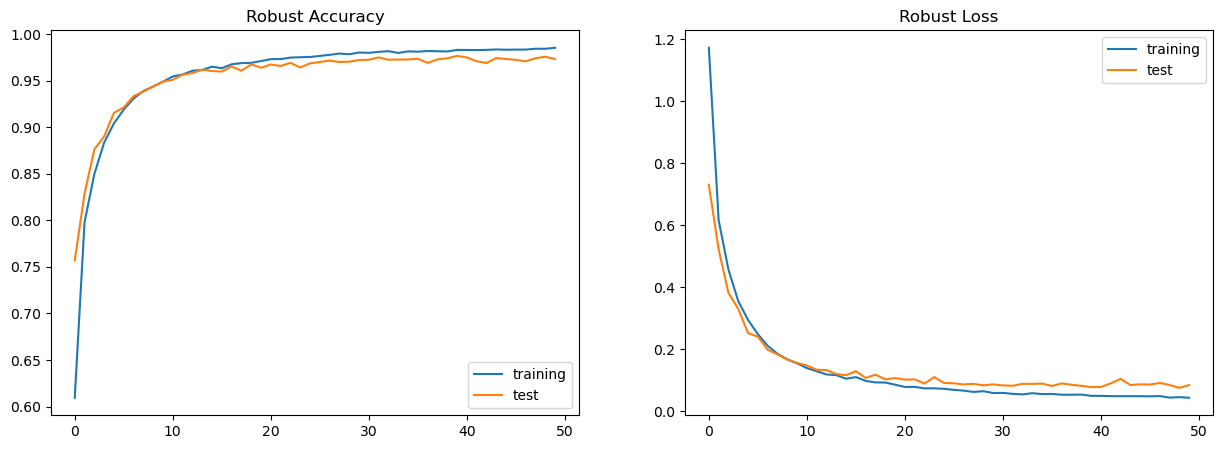

In [12]:
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(EPOCH)]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Robust Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Robust Loss')

plt.show()

## 11.4 鲁棒性测试

### 11.4.0 遮蔽攻击测试

In [13]:
# 加载样本
imgs, lbls = load_mnist_test()

# 遮蔽攻击测试
occlusion = OcclusionAttack(cnn, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')
occ_acc, _ = test_fn(nn.Sequential(occlusion, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'遮蔽攻击AT模型 - Clean: {cln_acc:.2f}, Occlusion Attack: {occ_acc:.2f}')

 32996 20260316 00:42:03 遮蔽攻击AT模型 - Clean: 95.75, Occlusion Attack: 97.34


### 11.4.1 白盒攻击测试（PGD, FGSM, CW）

In [14]:
EPS = 0.1

# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')
cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'遮蔽攻击AT模型 - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}, Occlusion: {occ_acc:.2f}')

 32996 20260316 00:42:06 遮蔽攻击AT模型 - Clean: 95.75, FGSM: 3.24, PGD: 0.00, CW: 0.00, Occlusion: 97.34


### 11.4.2 迁移攻击测试

In [ ]:
# 使用标准模型作为替代模型进行迁移攻击
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义迁移攻击参数（基于标准模型生成对抗性样本，测试遮蔽攻击AT模型）
FGSM_kwargs = dict(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 遮蔽迁移攻击
occlusion_transfer = OcclusionAttack(std_lenet, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

# 执行迁移攻击测试
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')
trans_occ_acc, _ = test_fn(nn.Sequential(occlusion_transfer, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'迁移攻击 - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}, Occlusion: {trans_occ_acc:.2f}')

### 11.4.3 结果汇总

In [ ]:
# ========== 攻击样本详细统计与白盒/迁移攻击对比分析 ==========
import pandas as pd
import numpy as np

def detailed_attack_analysis(model, imgs, lbls, test_fn, 
                            top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE,
                            eps=0.1, num_samples=10000):
    """
    详细分析白盒攻击和迁移攻击的效果差异
    """
    print("\n" + "="*70)
    print("白盒攻击 vs 迁移攻击 详细对比分析")
    print("="*70)
    
    # 加载替代模型（标准模型）
    std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
    std_lenet = LeNet5()
    std_lenet.load_state_dict(std_state['net'])
    std_lenet = std_lenet.to(device)
    std_lenet.eval()
    
    # 限制样本数量以加快分析
    sample_imgs = imgs[:num_samples].to(device)
    sample_lbls = lbls[:num_samples].to(device)
    
    results = {
        '攻击类型': [],
        '白盒准确率': [],
        '迁移准确率': [],
        '白盒攻击成功率': [],
        '迁移攻击成功率': [],
        '迁移性差异': []
    }
    
    attack_configs = [
        ('FGSM', LinfPGD, {'eps': eps, 'step': 1, 'step_size': eps, 'random_start': False}),
        ('PGD', LinfPGD, {'eps': eps, 'step': 20, 'step_size': 0.025, 'random_start': True}),
        ('CW', LinfPGD, {'eps': eps, 'step': 20, 'step_size': 0.025, 'random_start': True, 'criterion': CWLoss}),
        ('遮蔽攻击', OcclusionAttack, {'top_k': top_k, 'occlu_color': occlu_color, 'kernel_size': kernel_size})
    ]
    
    for attack_name, AttackClass, kwargs in attack_configs:
        # 白盒攻击（基于目标模型）
        if attack_name == '遮蔽攻击':
            attack_white = AttackClass(model, **kwargs)
        else:
            kwargs_wb = kwargs.copy()
            kwargs_wb['net'] = model
            attack_white = AttackClass(**kwargs_wb)
        
        # 迁移攻击（基于替代模型）
        if attack_name == '遮蔽攻击':
            attack_transfer = AttackClass(std_lenet, **kwargs)
        else:
            kwargs_tb = kwargs.copy()
            kwargs_tb['net'] = std_lenet
            attack_transfer = AttackClass(**kwargs_tb)
        
        # 测试白盒攻击
        white_acc, _ = test_fn(nn.Sequential(attack_white, model), 
                               sample_imgs, sample_lbls, bs=250, mode='attack')
        
        # 测试迁移攻击
        transfer_acc, _ = test_fn(nn.Sequential(attack_transfer, model), 
                                 sample_imgs, sample_lbls, bs=250, mode='attack')
        
        # 干净样本准确率（基准）
        clean_acc, _ = test_fn(model, sample_imgs, sample_lbls, bs=250, mode='clean')
        
        white_success = clean_acc - white_acc
        transfer_success = clean_acc - transfer_acc
        
        results['攻击类型'].append(attack_name)
        results['白盒准确率'].append(f"{white_acc:.2f}%")
        results['迁移准确率'].append(f"{transfer_acc:.2f}%")
        results['白盒攻击成功率'].append(f"{white_success:.2f}%")
        results['迁移攻击成功率'].append(f"{transfer_success:.2f}%")
        results['迁移性差异'].append(f"{abs(white_success - transfer_success):.2f}%")
        
        print(f"\n{attack_name}:")
        print(f"  白盒攻击准确率: {white_acc:.2f}% (成功率: {white_success:.2f}%)")
        print(f"  迁移攻击准确率: {transfer_acc:.2f}% (成功率: {transfer_success:.2f}%)")
        print(f"  迁移性差异: {abs(white_success - transfer_success):.2f}%")
    
    # 打印对比表格
    print("\n" + "="*70)
    print("白盒攻击 vs 迁移攻击 对比汇总表")
    print("="*70)
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    
    return results


# 对Occlusion-AT模型进行详细分析
print("\n对 Occlusion-AT 模型进行白盒/迁移攻击对比分析...")
occl_at_state = torch.load('./save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth', weights_only=True)
occl_at_model = LeNet5()
occl_at_model.load_state_dict(occl_at_state['net'])
occl_at_model = occl_at_model.to(device)
occl_at_model.eval()

results_occl_at = detailed_attack_analysis(
    occl_at_model, imgs, lbls, test_fn,
    top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE,
    num_samples=5000  # 使用5000个样本加快分析
)

# 对PGD-AT模型进行详细分析
print("\n对 PGD-AT 模型进行白盒/迁移攻击对比分析...")
pgd_at_path = './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth'
if os.path.exists(pgd_at_path):
    pgd_at_state = torch.load(pgd_at_path, weights_only=True)
    pgd_at_model = LeNet5()
    pgd_at_model.load_state_dict(pgd_at_state['net'])
    pgd_at_model = pgd_at_model.to(device)
    pgd_at_model.eval()
    
    results_pgd_at = detailed_attack_analysis(
        pgd_at_model, imgs, lbls, test_fn,
        top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE,
        num_samples=5000
    )
else:
    print(f"[WARN] PGD-AT模型未找到: {pgd_at_path}")

In [16]:
headers = ['模型', 'Clean', 'FGSM', 'PGD', 'CW', 'Occlusion']
table = [
    ['遮蔽攻击AT (白盒)', f'{cln_acc:.2f}', f'{fgsm_acc:.2f}', f'{pgd_acc:.2f}', f'{cw_acc:.2f}', f'{occ_acc:.2f}'],
    ['遮蔽攻击AT (迁移)', f'{cln_acc:.2f}', f'{trans_fgsm_acc:.2f}', f'{trans_pgd_acc:.2f}', f'{trans_cw_acc:.2f}', f'{trans_occ_acc:.2f}'],
]
print(tabulate(table, headers=headers, tablefmt='grid'))

+-------------------+---------+--------+-------+-------+-------------+
| 模型              |   Clean |   FGSM |   PGD |    CW |   Occlusion |
+===================+=========+========+=======+=======+=============+
| 遮蔽攻击AT (白盒) |   95.75 |   3.24 |  0    |  0    |       97.34 |
+-------------------+---------+--------+-------+-------+-------------+
| 遮蔽攻击AT (迁移) |   95.75 |  88.13 | 89.67 | 91.79 |       94.77 |
+-------------------+---------+--------+-------+-------+-------------+


In [ ]:
import sys
from pathlib import Path

# 将 AutoAttack 源码目录加入路径
_aa_root = Path('.').resolve() / 'auto-attack' / 'auto-attack-master'
if _aa_root.is_dir():
    sys.path.insert(0, str(_aa_root))

# 加载 checkpoint：权重在字典的 'net' 键中
ckpt = torch.load(
    './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth',
    map_location=device,
    weights_only=True,
)
cnn = LeNet5()
cnn.load_state_dict(ckpt['net'])
cnn = cnn.to(device)
cnn.eval()

from autoattack import AutoAttack

# load_mnist_test 使用 ToTensor，像素在 [0,1]；Linf 常用 eps=8/255（与 CIFAR 论文设置一致）
#EPS = 8.0 / 255.0
#N_EX = 1000  # 标准 AutoAttack 较慢；评估全测试集可改为 None

#imgs, lbls = load_mnist_test(n_examples=N_EX)
imgs, lbls = load_mnist_test()
lbls = lbls.long()

adversary = AutoAttack(
    cnn,
    norm='Linf',
    eps=0.1,
    version='standard',
    device=str(device),
    verbose=True,
)
x_adv = adversary.run_standard_evaluation(imgs, lbls, bs=250)

In [ ]:
# 白盒攻击 vs 迁移攻击：对抗样本可视化
import matplotlib.pyplot as plt

# 中文字体/负号兼容
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


def to_numpy(img):
    """把(1,28,28) tensor 转成(28,28)用于imshow"""
    return img.detach().cpu().squeeze().numpy()


def select_one_per_digit(imgs_tensor, lbls_tensor):
    """从整个测试集中抽取0-9各一个样本，返回digit_order对应的索引列表"""
    label_to_idx = {}
    for i in range(lbls_tensor.shape[0]):
        label = int(lbls_tensor[i].item())
        if label not in label_to_idx:
            label_to_idx[label] = i
        if len(label_to_idx) == 10:
            break
    # 按数字0-9顺序组织
    selected = []
    for d in range(10):
        if d in label_to_idx:
            selected.append(label_to_idx[d])
        else:
            selected.append(None)
    return selected


def plot_clean_and_adv(x_clean_10, x_adv_10, fig_title):
    """画1张大图：10行2列；每行=数字d；左列干净，右列对抗"""
    fig, axes = plt.subplots(10, 2, figsize=(8, 22))

    # axes[d, 0]：干净；axes[d, 1]：对抗
    for d in range(10):
        ax_clean = axes[d, 0]
        ax_adv = axes[d, 1]

        ax_clean.set_xticks([])
        ax_clean.set_yticks([])
        ax_adv.set_xticks([])
        ax_adv.set_yticks([])

        ax_clean.set_title(f'数字{d}-干净', fontsize=9)
        ax_adv.set_title(f'数字{d}-对抗', fontsize=9)

        img_clean = x_clean_10[d]
        img_adv = x_adv_10[d]

        ax_clean.imshow(to_numpy(img_clean), cmap='gray')
        ax_clean.axis('off')

        ax_adv.imshow(to_numpy(img_adv), cmap='gray')
        ax_adv.axis('off')

    fig.suptitle(fig_title, fontsize=14)
    plt.tight_layout()
    plt.show()


# 准备数据
if 'imgs' not in globals() or 'lbls' not in globals():
    imgs, lbls = load_mnist_test()

# 攻击参数（与前文保持一致）
EPS = 0.1

TOP_K_ = globals().get('TOP_K', 5)
OCCLU_COLOR_ = globals().get('OCCLU_COLOR', 0.0)
KERNEL_SIZE_ = globals().get('KERNEL_SIZE', 3)

# 选择0-9每个数字一个样本（仅取10张用于可视化，加快计算）
selected_indices = select_one_per_digit(imgs, lbls)

# 若个别数字缺失，给出提示
if any(s is None for s in selected_indices):
    raise RuntimeError(f'用于可视化的样本不足，缺失数字: {[i for i,s in enumerate(selected_indices) if s is None]}')

x_clean = imgs[selected_indices].to(device)
# x_clean 的第0维顺序即 digit=0..9

# ========== 1) 白盒攻击（针对cnn）==========
cnn.eval()

FGSM_w = LinfPGD(net=cnn, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_w = LinfPGD(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_w = LinfPGD(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
Occl_w = OcclusionAttack(cnn, top_k=TOP_K_, occlu_color=OCCLU_COLOR_, kernel_size=KERNEL_SIZE_)

# 注意：LinfPGD/ OcclusionAttack forward 需要输入(x,y)
# y 用于计算loss/target，因此需要从对应索引取标签
y_clean = lbls[selected_indices].to(device)

x_adv_fgsm_white = FGSM_w((x_clean, y_clean))
x_adv_pgd_white = PGD_w((x_clean, y_clean))
x_adv_cw_white = CW_w((x_clean, y_clean))
x_adv_occl_white = Occl_w((x_clean, y_clean))

plot_clean_and_adv(x_clean, x_adv_fgsm_white, '白盒攻击：FGSM')
plot_clean_and_adv(x_clean, x_adv_pgd_white, '白盒攻击：PGD')
plot_clean_and_adv(x_clean, x_adv_cw_white, '白盒攻击：CW')
plot_clean_and_adv(x_clean, x_adv_occl_white, '白盒攻击：遮蔽（Occlusion）')


# ========== 2) 迁移攻击（来源std_lenet，测试cnn）==========
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

FGSM_t = LinfPGD(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_t = LinfPGD(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_t = LinfPGD(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
Occl_t = OcclusionAttack(std_lenet, top_k=TOP_K_, occlu_color=OCCLU_COLOR_, kernel_size=KERNEL_SIZE_)

x_adv_fgsm_transfer = FGSM_t((x_clean, y_clean))
x_adv_pgd_transfer = PGD_t((x_clean, y_clean))
x_adv_cw_transfer = CW_t((x_clean, y_clean))
x_adv_occl_transfer = Occl_t((x_clean, y_clean))

plot_clean_and_adv(x_clean, x_adv_fgsm_transfer, '迁移攻击：FGSM')
plot_clean_and_adv(x_clean, x_adv_pgd_transfer, '迁移攻击：PGD')
plot_clean_and_adv(x_clean, x_adv_cw_transfer, '迁移攻击：CW')
plot_clean_and_adv(x_clean, x_adv_occl_transfer, '迁移攻击：遮蔽（Occlusion）')

In [10]:
logger_.handlers = logger_.handlers[:1]

In [11]:
# 遮蔽攻击 + PGD 混合样本对抗性训练（新方法）
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

from pgd import LinfPGD
from occlusion_attack import OcclusionAttack


class OcclusionPgdMixedAdversarialTraining(nn.Module):
    """把一个batch里的样本按比例替换为：一部分=遮蔽攻击样本，一部分=PGD攻击样本。"""

    def __init__(
        self,
        model,
        top_k=9,
        occlu_color=0.0,
        kernel_size=3,
        eps=0.1,
        pgd_step=20,
        pgd_step_size=0.025,
        random_start=True,
        occlu_ratio=0.5,
        criterion=F.cross_entropy,
    ):
        super().__init__()
        self.model = model
        self.occlu_ratio = occlu_ratio

        # 生成对抗样本：遮蔽攻击 + PGD(L_inf)
        self.occlusion = OcclusionAttack(
            self.model,
            top_k=top_k,
            occlu_color=occlu_color,
            kernel_size=kernel_size,
        )
        self.pgd = LinfPGD(
            net=self.model,
            eps=eps,
            step_size=pgd_step_size,
            step=pgd_step,
            random_start=random_start,
            criterion=criterion,
        )

    def forward(self, x, y=None):
        if y is None:
            return self.model(x)

        training = self.model.training
        assert y is not None

        # 对抗样本生成阶段固定为eval（与其它AT实现一致）
        self.model.eval()

        bs = x.size(0)
        k = int(bs * self.occlu_ratio)

        if k <= 0:
            x_mix = self.pgd((x, y))
        elif k >= bs:
            x_mix = self.occlusion((x, y))
        else:
            x_adv_occl = self.occlusion((x, y))
            x_adv_pgd = self.pgd((x, y))

            # 保持batch大小不变：前k个用遮蔽，其余用PGD
            x_mix = x_adv_pgd.clone()
            x_mix[:k] = x_adv_occl[:k]

        # 恢复训练模式
        if training:
            self.model.train()

        return self.model(x_mix)


# ========== 训练配置（按需修改）==========
EPOCH_MIX = 10
LR_MIX = 0.001

# PGD参数（L_inf）
EPS = 0.1
PGD_STEP = 20
PGD_STEP_SIZE = 0.025
RANDOM_START = True

# 混合比例：前k个走遮蔽，其余走PGD
OCCLU_RATIO = 0.5

# occlusion参数复用你前面定义的TOP_K / OCCLU_COLOR / KERNEL_SIZE
TOP_K_ = globals().get('TOP_K', 9)
OCCLU_COLOR_ = globals().get('OCCLU_COLOR', 0.0)
KERNEL_SIZE_ = globals().get('KERNEL_SIZE', 3)

# logger 兼容 + 日志保护：避免重复 StreamHandler 导致一条日志打印多遍
import logging

logger_ = globals().get('logger', None)
if logger_ is None:
    logger_ = logging.getLogger('base')
    logger_.setLevel(logging.DEBUG)

_stream_hs = [h for h in logger_.handlers if isinstance(h, logging.StreamHandler)]
if not _stream_hs:
    _h = logging.StreamHandler()
    _h.setLevel(logging.DEBUG)
    logger_.addHandler(_h)
else:
    for _h in _stream_hs[1:]:
        logger_.removeHandler(_h)

# ========== 构建模型与训练模块==========
cnn_mix = LeNet5().to(device)
cnn_mix_at = OcclusionPgdMixedAdversarialTraining(
    cnn_mix,
    top_k=TOP_K_,
    occlu_color=OCCLU_COLOR_,
    kernel_size=KERNEL_SIZE_,
    eps=EPS,
    pgd_step=PGD_STEP,
    pgd_step_size=PGD_STEP_SIZE,
    random_start=RANDOM_START,
    occlu_ratio=OCCLU_RATIO,
    criterion=F.cross_entropy,
)

optimizer_mix = torch.optim.Adam(cnn_mix.parameters(), lr=LR_MIX)
loss_function_ = nn.CrossEntropyLoss()


# ========== 训练/测试循环==========
train_accs, train_losses, test_accs, test_losses = [], [], [], []
train_clean_accs, test_clean_accs = [], []

for epoch in range(EPOCH_MIX):
    # 训练（对抗训练：模型内部会对inputs做混合攻击）
    cnn_mix_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_mix_at(inputs, labels)
        loss = loss_function_(outputs, labels)

        optimizer_mix.zero_grad()
        loss.backward()
        optimizer_mix.step()

        pred = outputs.max(dim=1).indices
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.item() * n

    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total

    # 干净样本准确率（不传 labels，走 forward 的干净分支）
    _was_train = cnn_mix_at.training
    cnn_mix_at.eval()
    train_clean_correct = 0
    with torch.no_grad():
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            pred_c = cnn_mix_at(inputs).max(dim=1).indices
            train_clean_correct += (pred_c == labels).sum().item()
    train_clean_acc = train_clean_correct / train_total
    if _was_train:
        cnn_mix_at.train()

    logger_.info(
        f'mix-AT train epoch: {epoch}, loss: {train_loss_avg:.2f}, '
        f'mix-acc: {100 * train_acc:.2f}%, clean-acc: {100 * train_clean_acc:.2f}%'
    )

    # 测试：同批次先算干净 acc，再走混合对抗（与训练一致）
    cnn_mix_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_clean_correct = 0
    test_total = 0

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)

            pred_clean = cnn_mix_at(inputs).max(dim=1).indices
            test_clean_correct += (pred_clean == labels).sum().item()

            outputs = cnn_mix_at(inputs, labels)
            loss = loss_function_(outputs, labels)

            pred = outputs.max(dim=1).indices
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n

    test_acc = test_correct / test_total
    test_clean_acc = test_clean_correct / test_total
    test_loss_avg = test_loss / test_total
    logger_.info(
        f'    mix-AT test epoch: {epoch}, loss: {test_loss_avg:.2f}, '
        f'mix-acc: {100 * test_acc:.2f}%, clean-acc: {100 * test_clean_acc:.2f}%'
    )

    train_accs.append(train_acc)
    train_losses.append(train_loss_avg)
    train_clean_accs.append(train_clean_acc)
    test_accs.append(test_acc)
    test_losses.append(test_loss_avg)
    test_clean_accs.append(test_clean_acc)


# ========== 保存模型（可选）==========
try:
    state = {
        'net': cnn_mix.state_dict(),
        'num_epoch': epoch,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'train_clean_accs': train_clean_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'test_clean_accs': test_clean_accs,
    }

    result_path = f'./save_model/{EPOCH_MIX}epoch'
    if not os.path.isdir(result_path):
        os.makedirs(result_path)

    torch.save(
        state,
        result_path + f'/mnist_lenet5_MixedOcclusionPgdAT_{OCCLU_RATIO}_{TOP_K_}_{KERNEL_SIZE_}.pth',
    )
except Exception as e:
    print('模型保存失败：', e)


mix-AT train epoch: 0, loss: 1.09, mix-acc: 62.60%, clean-acc: 95.05%
    mix-AT test epoch: 0, loss: 0.70, mix-acc: 75.27%, clean-acc: 95.43%
mix-AT train epoch: 1, loss: 0.62, mix-acc: 78.82%, clean-acc: 96.40%
    mix-AT test epoch: 1, loss: 0.55, mix-acc: 81.28%, clean-acc: 96.45%
mix-AT train epoch: 2, loss: 0.52, mix-acc: 82.18%, clean-acc: 97.14%
    mix-AT test epoch: 2, loss: 0.47, mix-acc: 83.92%, clean-acc: 97.27%
mix-AT train epoch: 3, loss: 0.47, mix-acc: 83.87%, clean-acc: 97.50%
    mix-AT test epoch: 3, loss: 0.45, mix-acc: 84.77%, clean-acc: 97.49%
mix-AT train epoch: 4, loss: 0.43, mix-acc: 85.01%, clean-acc: 97.71%
    mix-AT test epoch: 4, loss: 0.41, mix-acc: 86.10%, clean-acc: 97.81%
mix-AT train epoch: 5, loss: 0.41, mix-acc: 85.91%, clean-acc: 97.83%
    mix-AT test epoch: 5, loss: 0.39, mix-acc: 86.35%, clean-acc: 97.84%
mix-AT train epoch: 6, loss: 0.39, mix-acc: 86.64%, clean-acc: 98.31%
    mix-AT test epoch: 6, loss: 0.40, mix-acc: 86.28%, clean-acc: 98.36%

In [ ]:
# 加载 checkpoint：权重在字典的 'net' 键中
ckpt_mix = torch.load(
    './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth',
    map_location=device,
    weights_only=True,
)
cnn_mix = LeNet5()
cnn_mix.load_state_dict(ckpt_mix['net'])
cnn_mix = cnn_mix.to(device)
cnn_mix.eval()

In [13]:
# 加载样本
imgs, lbls = load_mnist_test()

# 遮蔽攻击测试
occlusion = OcclusionAttack(cnn_mix, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

cln_acc, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')
occ_acc, _ = test_fn(nn.Sequential(occlusion, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix攻击AT模型 - Clean: {cln_acc:.2f}, Occlusion Attack: {occ_acc:.2f}')

208472 20260328 16:07:22 Mix攻击AT模型 - Clean: 98.53, Occlusion Attack: 84.43
208472 20260328 16:07:22 Mix攻击AT模型 - Clean: 98.53, Occlusion Attack: 84.43


In [19]:
# ========== 混合攻击（mix-AT 模型）AutoAttack 测试 ==========
import sys
from pathlib import Path

# 确保 AutoAttack 可导入（与前面 AutoAttack cell 写法一致）
_aa_root = Path('.').resolve() / 'auto-attack' / 'auto-attack-master'
if _aa_root.is_dir():
    sys.path.insert(0, str(_aa_root))

from autoattack import AutoAttack

# 加载样本
imgs, lbls = load_mnist_test()
lbls = lbls.long()

# 选择 logger（兼容 notebook 里不同命名）
_logger = globals().get('logger', None) or globals().get('logger_', None)

# AutoAttack (Linf)
_eps_aa = globals().get('EPS', 0.1)

adversary = AutoAttack(
    cnn_mix,
    norm='Linf',
    eps=_eps_aa,
    version='standard',
    device=str(device),
    verbose=False,
)

x_adv = adversary.run_standard_evaluation(imgs, lbls, bs=250)

# clean / autoattack acc
# AutoAttack 已经在外部生成好 x_adv，这里直接把它当作“样本”评估即可。
cln_acc, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')
aa_acc, _ = test_fn(cnn_mix, x_adv, lbls, bs=250, mode='clean')

msg = f'mix-AT 模型 - Clean: {cln_acc:.2f}, AutoAttack(Linf, eps={_eps_aa}): {aa_acc:.2f}'
if _logger is not None:
    _logger.info(msg)
else:
    print(msg)


mix-AT 模型 - Clean: 98.53, AutoAttack(Linf, eps=0.1): 90.91


In [14]:
EPS = 0.1

# 定义攻击参数
FGSM_kwargs = dict(net=cnn_mix, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=cnn_mix, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn_mix, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn_mix), imgs, lbls, bs=250, mode='attack')
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn_mix), imgs, lbls, bs=250, mode='attack')
cw_acc, _ = test_fn(nn.Sequential(CW, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix攻击AT模型 - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}, Occlusion: {occ_acc:.2f}')

208472 20260328 16:07:34 Mix攻击AT模型 - Clean: 98.53, FGSM: 93.50, PGD: 91.71, CW: 91.67, Occlusion: 84.43
208472 20260328 16:07:34 Mix攻击AT模型 - Clean: 98.53, FGSM: 93.50, PGD: 91.71, CW: 91.67, Occlusion: 84.43


In [ ]:
# ========== PGD-AT模型对遮蔽攻击防御率异常问题排查 ==========
# 测试不同强度的遮蔽攻击在不同模型上的效果，绘制强度-准确率曲线

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def test_occlusion_strength_curve(models_dict, imgs, lbls, test_fn,
                                  top_k_values=[1, 2, 3, 5, 7, 9],
                                  kernel_size=3, num_samples=5000):
    """
    测试不同遮蔽攻击强度（top_k）下各模型的防御效果
    绘制强度-准确率曲线
    """
    print("\n" + "="*70)
    print("遮蔽攻击强度-准确率曲线测试")
    print("="*70)
    print(f"测试参数: kernel_size={kernel_size}, top_k_values={top_k_values}")
    print(f"测试样本数: {num_samples}")
    
    sample_imgs = imgs[:num_samples].to(device)
    sample_lbls = lbls[:num_samples].to(device)
    
    # 存储结果
    results = {name: {'top_k': [], 'clean_acc': [], 'occ_acc': []} 
               for name in models_dict.keys()}
    
    # 对每个模型测试不同强度的遮蔽攻击
    for model_name, model in models_dict.items():
        print(f"\n正在测试模型: {model_name}")
        model.eval()
        
        # 干净样本准确率
        clean_acc, _ = test_fn(model, sample_imgs, sample_lbls, bs=250, mode='clean')
        print(f"  干净样本准确率: {clean_acc:.2f}%")
        
        for top_k in top_k_values:
            # 创建遮蔽攻击
            occlusion = OcclusionAttack(model, top_k=top_k, occlu_color=0.0, kernel_size=kernel_size)
            
            # 测试遮蔽攻击准确率
            occ_acc, _ = test_fn(nn.Sequential(occlusion, model), 
                                sample_imgs, sample_lbls, bs=250, mode='attack')
            
            results[model_name]['top_k'].append(top_k)
            results[model_name]['clean_acc'].append(clean_acc)
            results[model_name]['occ_acc'].append(occ_acc)
            
            print(f"    top_k={top_k}: 遮蔽攻击准确率={occ_acc:.2f}%")
    
    # 绘制曲线
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 图1: 遮蔽攻击准确率随top_k变化
    ax1 = axes[0]
    for model_name, data in results.items():
        ax1.plot(data['top_k'], data['occ_acc'], marker='o', linewidth=2, label=model_name)
    ax1.set_xlabel('top_k (遮蔽区域数量)', fontsize=12)
    ax1.set_ylabel('准确率 (%)', fontsize=12)
    ax1.set_title(f'遮蔽攻击准确率随攻击强度变化 (kernel_size={kernel_size})', fontsize=12)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 100)
    
    # 图2: 攻击成功率 (Clean - Occlusion)
    ax2 = axes[1]
    for model_name, data in results.items():
        success_rate = [clean - occ for clean, occ in 
                       zip(data['clean_acc'], data['occ_acc'])]
        ax2.plot(data['top_k'], success_rate, marker='s', linewidth=2, label=model_name)
    ax2.set_xlabel('top_k (遮蔽区域数量)', fontsize=12)
    ax2.set_ylabel('攻击成功率 (%)', fontsize=12)
    ax2.set_title(f'遮蔽攻击成功率随攻击强度变化', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印汇总表格
    print("\n" + "="*70)
    print("遮蔽攻击强度-准确率汇总表")
    print("="*70)
    
    rows = []
    for model_name, data in results.items():
        for i, top_k in enumerate(data['top_k']):
            rows.append({
                '模型': model_name,
                'top_k': top_k,
                '干净准确率': f"{data['clean_acc'][i]:.2f}%",
                '遮蔽攻击准确率': f"{data['occ_acc'][i]:.2f}%",
                '攻击成功率': f"{data['clean_acc'][i] - data['occ_acc'][i]:.2f}%"
            })
    
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    
    return results


# 加载需要对比的模型
models_to_compare = {}

# 1. 标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_model = LeNet5()
std_model.load_state_dict(std_state['net'])
std_model = std_model.to(device)
models_to_compare['标准模型'] = std_model

# 2. Occlusion-AT模型 (top_k=9)
occl_state = torch.load('./save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth', weights_only=True)
occl_model = LeNet5()
occl_model.load_state_dict(occl_state['net'])
occl_model = occl_model.to(device)
models_to_compare['Occlusion-AT'] = occl_model

# 3. PGD-AT模型
pgd_path = './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth'
if os.path.exists(pgd_path):
    pgd_state = torch.load(pgd_path, weights_only=True)
    pgd_model = LeNet5()
    pgd_model.load_state_dict(pgd_state['net'])
    pgd_model = pgd_model.to(device)
    models_to_compare['PGD-AT'] = pgd_model

# 4. Mix-AT模型
mix_path = './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth'
if os.path.exists(mix_path):
    mix_state = torch.load(mix_path, weights_only=True)
    mix_model = LeNet5()
    mix_model.load_state_dict(mix_state['net'])
    mix_model = mix_model.to(device)
    models_to_compare['Mix-AT(Occl+PGD)'] = mix_model

# 运行对比实验
strength_results = test_occlusion_strength_curve(
    models_to_compare, imgs, lbls, test_fn,
    top_k_values=[1, 2, 3, 5, 7, 9],
    kernel_size=3,
    num_samples=5000
)

# 重点分析PGD-AT vs 标准模型
print("\n" + "="*70)
print("【重点分析】PGD-AT vs 标准模型 对遮蔽攻击的防御差异")
print("="*70)

if 'PGD-AT' in models_to_compare:
    pgd_data = strength_results['PGD-AT']
    std_data = strength_results['标准模型']
    
    print(f"\n在 top_k=9 时:")
    print(f"  标准模型遮蔽攻击准确率: {std_data['occ_acc'][-1]:.2f}%")
    if len(pgd_data['occ_acc']) > 0:
        print(f"  PGD-AT遮蔽攻击准确率: {pgd_data['occ_acc'][-1]:.2f}%")
        diff = pgd_data['occ_acc'][-1] - std_data['occ_acc'][-1]
        print(f"  差异: {diff:+.2f}%")
        
        if diff > 0:
            print(f"\n  [发现] PGD-AT对遮蔽攻击的防御率确实高于标准模型!")
            print(f"  这与论文预期相反，论文预期PGD-AT应该比标准模型更脆弱。")
        else:
            print(f"\n  [符合预期] PGD-AT对遮蔽攻击的防御率低于标准模型。")

# 分析不同kernel_size的影响
print("\n" + "="*70)
print("进一步分析：不同遮蔽窗口大小(kernel_size)的影响")
print("="*70)

kernel_sizes = [2, 3, 5]
top_k_fixed = 5

for ks in kernel_sizes:
    print(f"\n--- kernel_size={ks}, top_k={top_k_fixed} ---")
    for model_name, model in models_to_compare.items():
        occlusion = OcclusionAttack(model, top_k=top_k_fixed, occlu_color=0.0, kernel_size=ks)
        occ_acc, _ = test_fn(nn.Sequential(occlusion, model), 
                            imgs[:3000].to(device), lbls[:3000].to(device), 
                            bs=250, mode='attack')
        print(f"  {model_name}: {occ_acc:.2f}%")

In [ ]:
# ========== 不同遮蔽颜色对比实验 ==========
# 测试黑色(0.0)、灰色(0.5)、白色(1.0)遮蔽的效果

print("\n" + "="*80)
print("遮蔽颜色对比实验")
print("="*80)

occlu_colors = [0.0, 0.5, 1.0]  # 黑、灰、白
color_names = {0.0: '黑色(0.0)', 0.5: '灰色(0.5)', 1.0: '白色(1.0)'}
top_k_values_color = [3, 5, 9]
kernel_size = 3
num_samples = 5000

# 加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_model = LeNet5()
std_model.load_state_dict(std_state['net'])
std_model = std_model.to(device)
std_model.eval()

# 准备测试数据
imgs_test, lbls_test = load_mnist_test()
sample_imgs = imgs_test[:num_samples].to(device)
sample_lbls = lbls_test[:num_samples].to(device)

# 干净样本准确率
clean_acc, _ = test_fn(std_model, sample_imgs, sample_lbls, bs=250, mode='clean')
print(f"干净样本准确率: {clean_acc:.2f}%\n")

color_results = []

for occlu_color in occlu_colors:
    print(f"\n【{color_names[occlu_color]}】")
    print("-" * 50)
    
    for top_k in top_k_values_color:
        occlusion = OcclusionAttack(std_model, top_k=top_k, occlu_color=occlu_color, kernel_size=kernel_size)
        occ_acc, _ = test_fn(nn.Sequential(occlusion, std_model), 
                            sample_imgs, sample_lbls, bs=250, mode='attack')
        
        color_results.append({
            '遮蔽颜色': color_names[occlu_color],
            'top_k': top_k,
            'kernel_size': kernel_size,
            '干净准确率': clean_acc,
            '遮蔽攻击准确率': occ_acc,
            '攻击成功率': clean_acc - occ_acc
        })
        
        print(f"  top_k={top_k}: acc={occ_acc:.2f}%, success_rate={clean_acc - occ_acc:.2f}%")

# 结果汇总
color_df = pd.DataFrame(color_results)
print("\n" + "="*80)
print("遮蔽颜色对比结果汇总")
print("="*80)
print(color_df.to_string(index=False))

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率对比
ax1 = axes[0]
for color in color_names.values():
    data = color_df[color_df['遮蔽颜色'] == color]
    ax1.plot(data['top_k'], data['遮蔽攻击准确率'], marker='o', linewidth=2, label=color)
ax1.set_xlabel('top_k')
ax1.set_ylabel('准确率 (%)')
ax1.set_title('不同遮蔽颜色 - 攻击准确率对比')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# 攻击成功率对比
ax2 = axes[1]
for color in color_names.values():
    data = color_df[color_df['遮蔽颜色'] == color]
    ax2.plot(data['top_k'], data['攻击成功率'], marker='s', linewidth=2, label=color)
ax2.set_xlabel('top_k')
ax2.set_ylabel('攻击成功率 (%)')
ax2.set_title('不同遮蔽颜色 - 攻击成功率对比')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./occlusion_color_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n遮蔽颜色对比图已保存到: ./occlusion_color_comparison.png")

In [ ]:
# ========== 参数扫描实验：不同遮蔽攻击参数组合的全面测试 ==========
# 测试多种 top_k 和 kernel_size 组合，记录所有结果

import itertools
import pandas as pd
import matplotlib.pyplot as plt
import time

print("\n" + "="*80)
print("参数扫描实验：遮蔽攻击参数组合全面测试")
print("="*80)

# 参数组合
top_k_values = [3, 5, 7, 9]
kernel_size_values = [2, 3, 5]
num_samples = 10000

# 加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_model = LeNet5()
std_model.load_state_dict(std_state['net'])
std_model = std_model.to(device)
std_model.eval()

# 加载各种对抗训练模型
models_dict = {'标准模型': std_model}

# Occlusion-AT
occl_path = './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth'
if os.path.exists(occl_path):
    occl_state = torch.load(occl_path, weights_only=True)
    occl_model = LeNet5()
    occl_model.load_state_dict(occl_state['net'])
    occl_model = occl_model.to(device)
    models_dict['Occlusion-AT'] = occl_model

# PGD-AT
pgd_path = './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth'
if os.path.exists(pgd_path):
    pgd_state = torch.load(pgd_path, weights_only=True)
    pgd_model = LeNet5()
    pgd_model.load_state_dict(pgd_state['net'])
    pgd_model = pgd_model.to(device)
    models_dict['PGD-AT'] = pgd_model

# FGSM-AT
fgsm_path = './save_model/50epoch/mnist_lenet5_FGSM_AT.pth'
if os.path.exists(fgsm_path):
    fgsm_state = torch.load(fgsm_path, weights_only=True)
    fgsm_model = LeNet5()
    fgsm_model.load_state_dict(fgsm_state['net'])
    fgsm_model = fgsm_model.to(device)
    models_dict['FGSM-AT'] = fgsm_model

# Mix-AT
mix_path = './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth'
if os.path.exists(mix_path):
    mix_state = torch.load(mix_path, weights_only=True)
    mix_model = LeNet5()
    mix_model.load_state_dict(mix_state['net'])
    mix_model = mix_model.to(device)
    models_dict['Mix-AT'] = mix_model

print(f"\n加载的模型: {list(models_dict.keys())}")
print(f"参数组合: top_k={top_k_values}, kernel_size={kernel_size_values}")
print(f"测试样本数: {num_samples}")

# 准备测试数据
imgs_test, lbls_test = load_mnist_test()
sample_imgs = imgs_test[:num_samples].to(device)
sample_lbls = lbls_test[:num_samples].to(device)

# 存储所有结果
all_results = []

# 遍历所有参数组合
total_combinations = len(top_k_values) * len(kernel_size_values) * len(models_dict)
print(f"\n总测试组合数: {total_combinations}")
print("-" * 80)

counter = 0
for model_name, model in models_dict.items():
    model.eval()
    
    # 干净样本准确率
    clean_acc, _ = test_fn(model, sample_imgs, sample_lbls, bs=250, mode='clean')
    print(f"\n[{model_name}] 干净样本准确率: {clean_acc:.2f}%")
    
    for top_k in top_k_values:
        for kernel_size in kernel_size_values:
            counter += 1
            start_time = time.time()
            
            # 创建遮蔽攻击
            occlusion = OcclusionAttack(model, top_k=top_k, occlu_color=0.0, kernel_size=kernel_size)
            
            # 测试遮蔽攻击准确率
            occ_acc, _ = test_fn(nn.Sequential(occlusion, model), 
                                sample_imgs, sample_lbls, bs=250, mode='attack')
            
            # 计算攻击成功率
            attack_success_rate = clean_acc - occ_acc
            elapsed_time = time.time() - start_time
            
            # 记录结果
            result = {
                '模型': model_name,
                'top_k': top_k,
                'kernel_size': kernel_size,
                '干净准确率': clean_acc,
                '遮蔽攻击准确率': occ_acc,
                '攻击成功率': attack_success_rate,
                '测试时间(秒)': round(elapsed_time, 2)
            }
            all_results.append(result)
            
            print(f"  [{counter}/{total_combinations}] top_k={top_k}, kernel_size={kernel_size}: "
                  f"acc={occ_acc:.2f}%, success_rate={attack_success_rate:.2f}%, time={elapsed_time:.1f}s")

# 创建结果DataFrame
results_df = pd.DataFrame(all_results)
print("\n" + "="*80)
print("参数扫描结果汇总")
print("="*80)
print(results_df.to_string(index=False))

# 保存结果到CSV
results_csv_path = './occlusion_parameter_scan_results.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"\n结果已保存到: {results_csv_path}")

# 绘制热力图
fig, axes = plt.subplots(2, len(models_dict), figsize=(5*len(models_dict), 10))
if len(models_dict) == 1:
    axes = axes.reshape(2, 1)

for idx, model_name in enumerate(models_dict.keys()):
    model_data = results_df[results_df['模型'] == model_name]
    
    # 透视表：x=kernel_size, y=top_k, values=遮蔽攻击准确率
    pivot_acc = model_data.pivot(index='top_k', columns='kernel_size', values='遮蔽攻击准确率')
    pivot_success = model_data.pivot(index='top_k', columns='kernel_size', values='攻击成功率')
    
    # 准确率热力图
    ax1 = axes[0, idx]
    im1 = ax1.imshow(pivot_acc.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    ax1.set_xticks(range(len(kernel_size_values)))
    ax1.set_yticks(range(len(top_k_values)))
    ax1.set_xticklabels(kernel_size_values)
    ax1.set_yticklabels(top_k_values)
    ax1.set_xlabel('kernel_size')
    ax1.set_ylabel('top_k')
    ax1.set_title(f'{model_name}\n遮蔽攻击准确率(%)')
    
    # 添加数值标注
    for i in range(len(top_k_values)):
        for j in range(len(kernel_size_values)):
            text = ax1.text(j, i, f'{pivot_acc.values[i, j]:.1f}',
                           ha="center", va="center", color="black", fontsize=9)
    
    plt.colorbar(im1, ax=ax1)
    
    # 攻击成功率热力图
    ax2 = axes[1, idx]
    im2 = ax2.imshow(pivot_success.values, cmap='Reds', aspect='auto', vmin=0, vmax=100)
    ax2.set_xticks(range(len(kernel_size_values)))
    ax2.set_yticks(range(len(top_k_values)))
    ax2.set_xticklabels(kernel_size_values)
    ax2.set_yticklabels(top_k_values)
    ax2.set_xlabel('kernel_size')
    ax2.set_ylabel('top_k')
    ax2.set_title(f'{model_name}\n攻击成功率(%)')
    
    # 添加数值标注
    for i in range(len(top_k_values)):
        for j in range(len(kernel_size_values)):
            text = ax2.text(j, i, f'{pivot_success.values[i, j]:.1f}',
                           ha="center", va="center", color="black", fontsize=9)
    
    plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig('./occlusion_parameter_scan_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n热力图已保存到: ./occlusion_parameter_scan_heatmap.png")

print("\n" + "="*80)
print("参数扫描实验完成！")
print("="*80)

In [ ]:
# 使用标准模型作为替代模型进行迁移攻击
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', weights_only=True)
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义迁移攻击参数（基于标准模型生成对抗性样本，测试遮蔽攻击AT模型）
FGSM_kwargs = dict(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 遮蔽迁移攻击
occlusion_transfer = OcclusionAttack(std_lenet, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

# 执行迁移攻击测试
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn_mix), imgs, lbls, bs=250, mode='attack')
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn_mix), imgs, lbls, bs=250, mode='attack')
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn_mix), imgs, lbls, bs=250, mode='attack')
trans_occ_acc, _ = test_fn(nn.Sequential(occlusion_transfer, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'迁移攻击 - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}, Occlusion: {trans_occ_acc:.2f}')

In [ ]:
# ========== 四类AT模型统一评测表（Clean / FGSM / PGD / CW / Occlusion）==========
import os
import pandas as pd

# 统一配置（若前面已定义则复用）
_eps = globals().get('EPS', 0.1)
_top_k = globals().get('TOP_K', 5)
_occlu_color = globals().get('OCCLU_COLOR', 0.0)
_kernel_size = globals().get('KERNEL_SIZE', 3)

# 加载测试集
imgs, lbls = load_mnist_test()

# 模型配置：名称 -> checkpoint路径
model_ckpts = {
    'Occlusion-AT': './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth',
    'PGD-AT': './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth',
    'FGSM-AT': './save_model/50epoch/mnist_lenet5_FGSM_AT.pth',
    'Mix-AT(Occlusion+PGD)': './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth',
}


def _load_model(ckpt_path):
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=True)
    net.load_state_dict(state['net'])
    net.eval()
    return net


def _eval_one_model(model_name, model):
    # clean
    clean_acc, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')

    # white-box attacks
    fgsm = LinfPGD(net=model, eps=_eps, step=1, step_size=_eps, random_start=False)
    pgd = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True)
    cw = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, model), imgs, lbls, bs=250, mode='attack')
    pgd_acc, _ = test_fn(nn.Sequential(pgd, model), imgs, lbls, bs=250, mode='attack')
    cw_acc, _ = test_fn(nn.Sequential(cw, model), imgs, lbls, bs=250, mode='attack')

    # occlusion attack
    occl = OcclusionAttack(model, top_k=_top_k, occlu_color=_occlu_color, kernel_size=_kernel_size)
    occl_acc, _ = test_fn(nn.Sequential(occl, model), imgs, lbls, bs=250, mode='attack')

    return {
        'Model': model_name,
        'Clean': round(clean_acc, 2),
        'FGSM': round(fgsm_acc, 2),
        'PGD': round(pgd_acc, 2),
        'CW': round(cw_acc, 2),
        'Occlusion': round(occl_acc, 2),
    }


rows = []
missing = []
for name, ckpt in model_ckpts.items():
    if not os.path.exists(ckpt):
        missing.append((name, ckpt))
        continue
    model = _load_model(ckpt)
    rows.append(_eval_one_model(name, model))

if missing:
    for n, p in missing:
        print(f'[WARN] 未找到模型权重，已跳过: {n} -> {p}')

if rows:
    result_df = pd.DataFrame(rows)[['Model', 'Clean', 'FGSM', 'PGD', 'CW', 'Occlusion']]
    display(result_df)

    _logger = globals().get('logger', None) or globals().get('logger_', None)
    if _logger is not None:
        _logger.info('四类AT模型统一评测结果:')
        for _, r in result_df.iterrows():
            _logger.info(
                f"{r['Model']} - Clean: {r['Clean']:.2f}, FGSM: {r['FGSM']:.2f}, "
                f"PGD: {r['PGD']:.2f}, CW: {r['CW']:.2f}, Occlusion: {r['Occlusion']:.2f}"
            )
else:
    print('没有可评测的模型，请先检查 checkpoint 路径。')

In [ ]:
# ========== 混合攻击（遮蔽 + PGD）白盒可视化（本格独立运行，不依赖前面变量）==========
import sys
import os
from pathlib import Path

_root = Path.cwd().resolve()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pgd import LinfPGD
from occlusion_attack import OcclusionAttack
from utils import load_mnist_test
from models import LeNet5
from loss import CWLoss

# 中文字体/负号
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 与混合 AT 训练一致的可调参数
EPS = 0.1
PGD_STEP = 20
PGD_STEP_SIZE = 0.025
OCCLU_RATIO = 0.5
TOP_K = 5
OCCLU_COLOR = 0.0
KERNEL_SIZE = 3

# 混合 AT 权重（与保存文件名一致；若你改了 EPOCH_MIX/比例，请改此路径）
CKPT_MIX = str(_root / 'save_model' / '10epoch' / 'mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth')


def to_numpy(img):
    return img.detach().cpu().squeeze().numpy()


def select_one_per_digit(imgs_tensor, lbls_tensor):
    label_to_idx = {}
    for i in range(lbls_tensor.shape[0]):
        label = int(lbls_tensor[i].item())
        if label not in label_to_idx:
            label_to_idx[label] = i
        if len(label_to_idx) == 10:
            break
    selected = []
    for d in range(10):
        selected.append(label_to_idx.get(d))
    return selected


def plot_clean_and_adv(x_clean_10, x_adv_10, fig_title):
    fig, axes = plt.subplots(10, 2, figsize=(8, 22))
    for d in range(10):
        ax_clean, ax_adv = axes[d, 0], axes[d, 1]
        for ax in (ax_clean, ax_adv):
            ax.set_xticks([])
            ax.set_yticks([])
        ax_clean.set_title(f'数字{d}-干净', fontsize=9)
        ax_adv.set_title(f'数字{d}-对抗', fontsize=9)
        ax_clean.imshow(to_numpy(x_clean_10[d]), cmap='gray')
        ax_clean.axis('off')
        ax_adv.imshow(to_numpy(x_adv_10[d]), cmap='gray')
        ax_adv.axis('off')
    fig.suptitle(fig_title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


def mixed_occlusion_pgd_batch(model, x, y, occlu_ratio, top_k, occlu_color, kernel_size, eps, pgd_step, pgd_step_size):
    """与 OcclusionPgdMixedAdversarialTraining 中 batch 混合规则一致：前 k 个遮蔽，其余 PGD。"""
    was_training = model.training
    model.eval()
    bs = x.size(0)
    k = int(bs * occlu_ratio)
    occlusion = OcclusionAttack(model, top_k=top_k, occlu_color=occlu_color, kernel_size=kernel_size)
    pgd = LinfPGD(
        net=model,
        eps=eps,
        step_size=pgd_step_size,
        step=pgd_step,
        random_start=True,
        criterion=F.cross_entropy,
    )
    if k <= 0:
        x_mix = pgd((x, y))
    elif k >= bs:
        x_mix = occlusion((x, y))
    else:
        x_o = occlusion((x, y))
        x_p = pgd((x, y))
        x_mix = x_p.clone()
        x_mix[:k] = x_o[:k]
    if was_training:
        model.train()
    return x_mix


if not os.path.isfile(CKPT_MIX):
    raise FileNotFoundError(f'未找到混合 AT 权重: {CKPT_MIX}（请先训练并保存，或修改 CKPT_MIX）')

imgs, lbls = load_mnist_test()
selected_indices = select_one_per_digit(imgs, lbls)
if any(i is None for i in selected_indices):
    raise RuntimeError(f'测试集中缺少数位: {[i for i, s in enumerate(selected_indices) if s is None]}')

x_clean = imgs[selected_indices].to(device)
y_clean = lbls[selected_indices].to(device).long()

net = LeNet5().to(device)
state = torch.load(CKPT_MIX, map_location=device, weights_only=True)
net.load_state_dict(state['net'])
net.eval()

# 白盒攻击（与 notebook 其它评测参数一致）
FGSM_w = LinfPGD(net=net, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_w = LinfPGD(net=net, eps=EPS, step=PGD_STEP, step_size=PGD_STEP_SIZE, random_start=True)
CW_w = LinfPGD(
    net=net,
    eps=EPS,
    step=PGD_STEP,
    step_size=PGD_STEP_SIZE,
    random_start=True,
    criterion=CWLoss,
)
Occl_w = OcclusionAttack(net, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

x_adv_fgsm = FGSM_w((x_clean, y_clean))
x_adv_pgd = PGD_w((x_clean, y_clean))
x_adv_cw = CW_w((x_clean, y_clean))
x_adv_occl = Occl_w((x_clean, y_clean))
x_adv_mixed = mixed_occlusion_pgd_batch(
    net,
    x_clean,
    y_clean,
    OCCLU_RATIO,
    TOP_K,
    OCCLU_COLOR,
    KERNEL_SIZE,
    EPS,
    PGD_STEP,
    PGD_STEP_SIZE,
)

_prefix = '白盒攻击（Mix-AT 模型）'
plot_clean_and_adv(x_clean, x_adv_fgsm, f'{_prefix}：FGSM')
plot_clean_and_adv(x_clean, x_adv_pgd, f'{_prefix}：PGD')
plot_clean_and_adv(x_clean, x_adv_cw, f'{_prefix}：CW')
plot_clean_and_adv(x_clean, x_adv_occl, f'{_prefix}：遮蔽（Occlusion）')
plot_clean_and_adv(
    x_clean,
    x_adv_mixed,
    f'{_prefix}：混合（遮蔽+PGD，batch 前{int(10 * OCCLU_RATIO)}个遮蔽/其余PGD）',
)